# Landscape scan — frustrated ring N=7, LZS(M=2) optimal control

Workflow (mirrors Pecci, Wang, Torta, Mbeng & Santoro, *"Beyond Quantum Annealing"*, App. C):

1. **Multi-restart** the GRAPE optimizer from several random seeds to find distinct local minima $\theta^*$ in the 7-dim LZS parameter space.
2. **Hessian** of $E(\theta)$ at a chosen $\theta^*$, via finite differences on the analytic GRAPE gradient (cheap — the gradient itself is exact).
3. **2D slice** of the landscape along the Hessian's stiffest/softest eigendirections, evaluating $E$, $M_2$ (SRE / magic), and $S_{vN}$ (entanglement) of the *final* state at every grid point.
4. Cross-check against a **random-direction** slice.

Self-contained: rebuilds the frustrated-ring Hamiltonians and Z2 +1-sector exactly as in `FrustratedRing.ipynb` (N=7, J=1.0, JL=0.5, JR=0.45, tau=50).

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
from tqdm import trange

from src.annealing_utils import get_longitudinal_hamiltonian, get_driver_hamiltonian
from src.utils import Z2SymmetricSector, EntanglementEntropy
from src.jax_utils import SREJax
from src.sparse_grape_method import SparseGRAPEModel, SparseGRAPETrainer

## Hamiltonian setup — frustrated ring, N=7

In [2]:
def frustrated_ring_jij_hz(N, J=1.0, JL=0.5, JR=0.45):
    """
    Build (jij, hz) for get_longitudinal_hamiltonian(jij, hz):
        H_p = -sum_{j=1}^N J_j Z_j Z_{j+1}   (site N+1 == site 1, 1-indexed j)
        J_j = -J_R if j==N ; J_L if j==(N-1)/2 or (N+1)/2 ; J otherwise
    """
    assert N % 2 == 1, "N must be odd"
    jij = np.zeros((N, N))
    mid1 = (N - 1) // 2
    mid2 = (N + 1) // 2
    for j in range(1, N + 1):
        if j == N:
            Jj = -JR
        elif j == mid1 or j == mid2:
            Jj = JL
        else:
            Jj = J
        i0 = j - 1
        i1 = j % N
        jij[i0, i1] += -Jj
        jij[i1, i0] += -Jj
    hz = np.zeros(N)
    return jij, hz


N = 7
J, JL, JR = 1.0, 0.5, 0.45
nqubits = N

jij, hz = frustrated_ring_jij_hz(N, J, JL, JR)
target_hamiltonian = get_longitudinal_hamiltonian(jij, hz)  # sparse, full 2^N
driver_hamiltonian = get_driver_hamiltonian(nqubits=nqubits)  # sparse, full 2^N

E0_formula = -(N - 3) * J + JR - 2 * JL
vals_full = np.sort(
    eigsh(
        target_hamiltonian.astype(complex), k=4, which="SA", return_eigenvectors=False
    )
)
print(f"E0 formula          : {E0_formula:.4f}")
print(f"E0,E1 numeric (full) : {np.round(vals_full, 4)}")

E0 formula          : -4.5500
E0,E1 numeric (full) : [-4.55 -4.55 -4.45 -4.45]


## Z2 +1-sector projection

Uses `Z2SymmetricSector` (the correct symmetric/antisymmetric-combination isometry, NOT `src.utils.Sector`'s naive index truncation).

In [3]:
sector = Z2SymmetricSector(nqubits, sign=+1)
dim = 2**nqubits

psi_init_full = np.ones(dim, dtype=complex) / np.sqrt(dim)
assert sector.check_confined(psi_init_full), "initial state not confined to +1 sector!"

target_hamiltonian_s = sector.project(target_hamiltonian)
driver_hamiltonian_s = sector.project(driver_hamiltonian)
psi_init_s = sector.project(psi_init_full)

print(f"Full space dim : {dim}")
print(f"Sector dim     : {sector.dim_sector}")
print(f"psi_init_s norm: {np.linalg.norm(psi_init_s):.10f}")

Z2SymmetricSector: 64 states out of 128 (sign=+1)
Full space dim : 128
Sector dim     : 64
psi_init_s norm: 1.0000000000


## Schedule hyperparameters — LZS(M=2), 7 parameters

In [4]:
tau = 50
time_steps = int(10 * tau)
number_parameters = 2  # M=2 plateaus/arms -> n_params = 3*M+1 = 7
schedule_type = "LZS"


def build_model(seed=42, random=False):
    return SparseGRAPEModel(
        initial_state=psi_init_s,
        target_hamiltonian=target_hamiltonian_s,
        initial_hamiltonian=driver_hamiltonian_s,
        reference_hamiltonian=target_hamiltonian_s,
        tf=tau,
        number_of_parameters=number_parameters,
        nsteps=time_steps,
        type=schedule_type,
        seed=seed,
        random=random,
    )

## Step 1 — multi-restart to find distinct local minima

L-BFGS-B on the 7-param LZS landscape from `n_restarts` random seeds; converged $\theta^*$'s are deduped by L2 distance in parameter space so re-converged seeds don't count twice.

In [5]:
def multi_restart_minima(n_restarts=20, dedupe_tol=1e-3, maxiter=500, verbose=True):
    candidates = []
    for seed in trange(n_restarts, desc="restarts"):
        model = build_model(seed=seed, random=True)
        trainer = SparseGRAPETrainer(model, maxiter=maxiter, verbose=False)
        res = trainer.run()
        candidates.append(
            {"theta": res["parameters"], "energy": res["energy"], "seed": seed}
        )

    candidates.sort(key=lambda c: c["energy"])

    minima = []
    for c in candidates:
        is_new = all(
            np.linalg.norm(c["theta"] - m["theta"]) > dedupe_tol for m in minima
        )
        if is_new:
            minima.append(c)

    if verbose:
        print(f"\n{len(minima)} distinct local minima out of {n_restarts} restarts:")
        for m in minima:
            print(f"  seed={m['seed']:3d}  E={m['energy']:.6f}")
    return minima


minima = multi_restart_minima(n_restarts=20)
theta_star = minima[0]["theta"]  # best (lowest-energy) minimum found
print("\nUsing theta* from the best minimum:", theta_star)

restarts: 100%|██████████| 20/20 [08:42<00:00, 26.13s/it]


20 distinct local minima out of 20 restarts:
  seed=  7  E=-4.530592
  seed= 13  E=-4.527013
  seed= 11  E=-4.526302
  seed=  6  E=-4.486664
  seed=  0  E=-4.485112
  seed= 16  E=-4.485003
  seed= 14  E=-4.484418
  seed=  9  E=-4.483410
  seed=  8  E=-4.483356
  seed=  1  E=-4.483124
  seed=  4  E=-4.483048
  seed= 18  E=-4.482597
  seed= 10  E=-4.482383
  seed= 17  E=-4.481487
  seed=  3  E=-4.479485
  seed= 15  E=-4.478762
  seed= 19  E=-4.478353
  seed= 12  E=-4.477675
  seed=  2  E=-4.477266
  seed=  5  E=-4.477196

Using theta* from the best minimum: [ 0.52216105  0.21656453  0.16642647 -0.61933866  0.05598444  1.47768591
  0.00655298]


## Step 2 — Hessian at theta*, eigendirections

Central finite differences on the *analytic* GRAPE gradient (cheap — 2×7 extra gradient evaluations, not a from-scratch FD Hessian).

In [6]:
def hessian_fd(model, theta_star, eps=1e-4):
    n = len(theta_star)
    H = np.zeros((n, n))
    for i in range(n):
        tp, tm = theta_star.copy(), theta_star.copy()
        tp[i] += eps
        tm[i] -= eps
        _, gp = model.forward_and_gradient(tp)
        _, gm = model.forward_and_gradient(tm)
        H[i, :] = (gp - gm) / (2 * eps)
    H = 0.5 * (H + H.T)  # symmetrize (FD Hessian isn't exactly symmetric)
    model.forward_and_gradient(theta_star)  # reset model state
    return H


def hessian_eigendirections(model, theta_star, eps=1e-4):
    H = hessian_fd(model, theta_star, eps)
    evals, evecs = np.linalg.eigh(H)
    return evecs[:, -1], evecs[:, 0], evals  # v_max, v_min, eigenvalues


def random_orthonormal_directions(n_params, seed=0):
    rng = np.random.default_rng(seed)
    v1 = rng.normal(size=n_params)
    v1 /= np.linalg.norm(v1)
    v2 = rng.normal(size=n_params)
    v2 -= (v2 @ v1) * v1
    v2 /= np.linalg.norm(v2)
    return v1, v2


model = build_model()
v_max, v_min, evals = hessian_eigendirections(model, theta_star)
print("Hessian eigenvalues:", np.round(evals, 5))
print("Stiffest direction (v_max):", np.round(v_max, 4))
print("Softest  direction (v_min):", np.round(v_min, 4))

Hessian eigenvalues: [-3.000000e-05  7.724000e-02  1.710800e-01  3.741500e-01  6.534600e-01
  2.244010e+00  1.142264e+01]
Stiffest direction (v_max): [-0.2357 -0.0063  0.0843  0.2504 -0.0351 -0.1207 -0.9267]
Softest  direction (v_min): [ 0.4939  0.4571  0.452   0.386   0.4404  0.     -0.    ]


## Step 3 — 2D scan along Hessian eigendirections

$\theta = \theta^* + \mu\, v_{max} + \nu\, v_{min}$. At every grid point: propagate to get the final sector-state, lift it to the full $2^N$ space (SRE / entanglement are functionals of the full-space wavefunction), and record $E$, $M_2$, $S_{vN}$.

**Note on grid range**: start with a modest $\mu,\nu$ range — the LZS durations go through a softplus, so large excursions can push segments toward degenerate/near-zero duration. Widen once the first heatmap looks sensible.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Building Pauli index tables for n=7 (16,384 Paulis)...
Done.
Bipartition: A=3 qubits (8d), B=4 qubits (16d)


landscape scan: 100%|██████████| 25/25 [04:32<00:00, 10.89s/it]


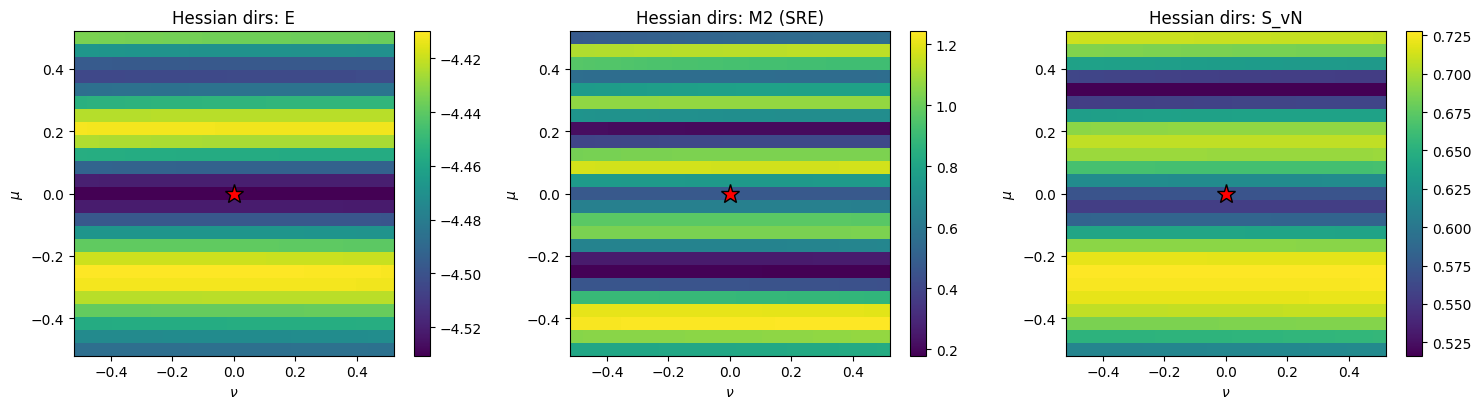

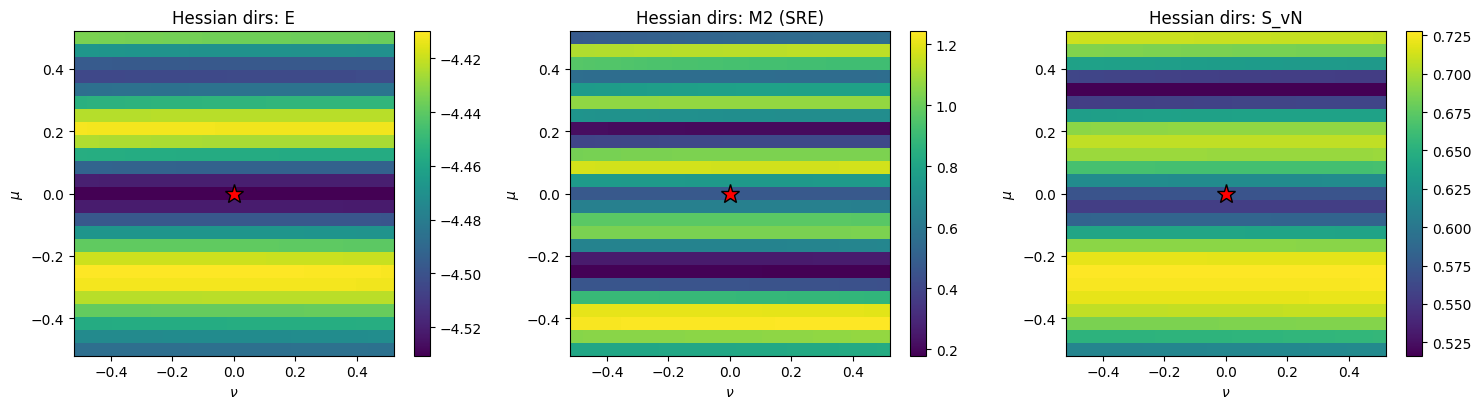

In [ ]:
from scipy.sparse.linalg import expm_multiply


def propagate_trajectory(
    model,
    theta,
    sector,
    driver_hamiltonian_s,
    target_hamiltonian_s,
    time_subsample=10,
    psi_init_s=None,
):
    """
    Full time-resolved propagation for a given theta. Returns psi_history_full
    (n_sub_steps, 2^n) — the state lifted to the full space at each *sampled*
    time step, plus the corresponding subsampled time indices.

    time_subsample: keep every k-th step. SRE is not free (4^n Paulis per
    call), so sampling every ~10-20 steps out of nsteps=500 is usually enough
    to resolve the magic profile without recomputing all 500.
    """
    model.forward_and_gradient(theta)  # syncs h_driver/h_target for this theta
    h_driver, h_target = model.get_driving()
    dt = model.dt

    idx = np.arange(0, model.nsteps, time_subsample)
    psi = psi_init_s.copy()
    psi_history_full = np.zeros((len(idx), sector.dim), dtype=complex)

    k = 0
    for i in range(model.nsteps):
        H_t = h_driver[i] * driver_hamiltonian_s + h_target[i] * target_hamiltonian_s
        psi = expm_multiply(-1j * dt * H_t, psi)
        if i in idx:
            psi_full = sector.lift(psi)
            psi_history_full[k] = psi_full / np.linalg.norm(psi_full)
            k += 1

    return psi_history_full, model.time[idx]


def scan_2d(
    model,
    center,
    v1,
    v2,
    sector,
    n_qubits,
    mu_range,
    nu_range,
    driver_hamiltonian_s,
    target_hamiltonian_s,
    psi_init_s=None,
    time_subsample=10,
    verbose=True,
):
    sre = SREJax(n_qubits)
    ent = EntanglementEntropy(n_qubits)
    nM, nN = len(mu_range), len(nu_range)

    E_grid = np.zeros((nM, nN))

    M2_mean_grid = np.zeros((nM, nN))
    M2_max_grid = np.zeros((nM, nN))
    M2_integral_grid = np.zeros((nM, nN))
    M2_final_grid = np.zeros((nM, nN))

    S_mean_grid = np.zeros((nM, nN))
    S_max_grid = np.zeros((nM, nN))
    S_integral_grid = np.zeros((nM, nN))
    S_final_grid = np.zeros((nM, nN))

    for i in trange(nM, desc="trajectory scan", disable=not verbose):
        for j in range(nN):
            theta = center + mu_range[i] * v1 + nu_range[j] * v2

            # energy: single cheap forward pass, no need for the full trajectory
            E, _ = model.forward_and_gradient(theta)
            E_grid[i, j] = E

            # full time-resolved propagation for magic + entanglement
            psi_hist, t_sub = propagate_trajectory(
                model,
                theta,
                sector,
                driver_hamiltonian_s,
                target_hamiltonian_s,
                time_subsample=time_subsample,
                psi_init_s=psi_init_s,
            )
            m2_t = np.array([sre(psi) for psi in psi_hist])
            s_t = np.array([ent.von_neumann(psi) for psi in psi_hist])

            M2_mean_grid[i, j] = m2_t.mean()
            M2_max_grid[i, j] = m2_t.max()
            M2_integral_grid[i, j] = np.trapz(m2_t, t_sub) / (t_sub[-1] - t_sub[0])
            M2_final_grid[i, j] = m2_t[-1]

            S_mean_grid[i, j] = s_t.mean()
            S_max_grid[i, j] = s_t.max()
            S_integral_grid[i, j] = np.trapz(s_t, t_sub) / (t_sub[-1] - t_sub[0])
            S_final_grid[i, j] = s_t[-1]

    model.forward_and_gradient(center)  # reset model state

    return {
        "E": E_grid,
        "M2_mean": M2_mean_grid,
        "M2_max": M2_max_grid,
        "M2_integral": M2_integral_grid,
        "M2_final": M2_final_grid,
        "S_mean": S_mean_grid,
        "S_max": S_max_grid,
        "S_integral": S_integral_grid,
        "S_final": S_final_grid,
    }


def plot_scan(mu_range, nu_range, E_grid, M2_grid, S_grid, title_prefix=""):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    for ax, grid, label in zip(
        axes, [E_grid, M2_grid, S_grid], ["E", "M2 (SRE)", "S_vN"]
    ):
        im = ax.pcolormesh(nu_range, mu_range, grid, shading="auto", cmap="viridis")
        ax.plot(0, 0, marker="*", color="red", markersize=14, markeredgecolor="k")
        ax.set_xlabel(r"$\nu$")
        ax.set_ylabel(r"$\mu$")
        ax.set_title(f"{title_prefix}{label}")
        fig.colorbar(im, ax=ax)
    fig.tight_layout()
    plt.show()
    return fig


mu_range = np.linspace(-0.5, 0.5, 25)
nu_range = np.linspace(-0.5, 0.5, 25)

E_hess, M2_hess, S_hess = scan_2d(
    model, theta_star, v_max, v_min, sector, nqubits, mu_range, nu_range
)
plot_scan(mu_range, nu_range, E_hess, M2_hess, S_hess, title_prefix="Hessian dirs: ")

## Step 4 — cross-check: random-direction slice

Is the Hessian-eigendirection picture representative of the landscape around $\theta^*$, or does it sit in an unusually shaped basin? Compare against two random orthonormal directions.

Building Pauli index tables for n=7 (16,384 Paulis)...
Done.
Bipartition: A=3 qubits (8d), B=4 qubits (16d)


landscape scan: 100%|██████████| 25/25 [05:07<00:00, 12.29s/it]


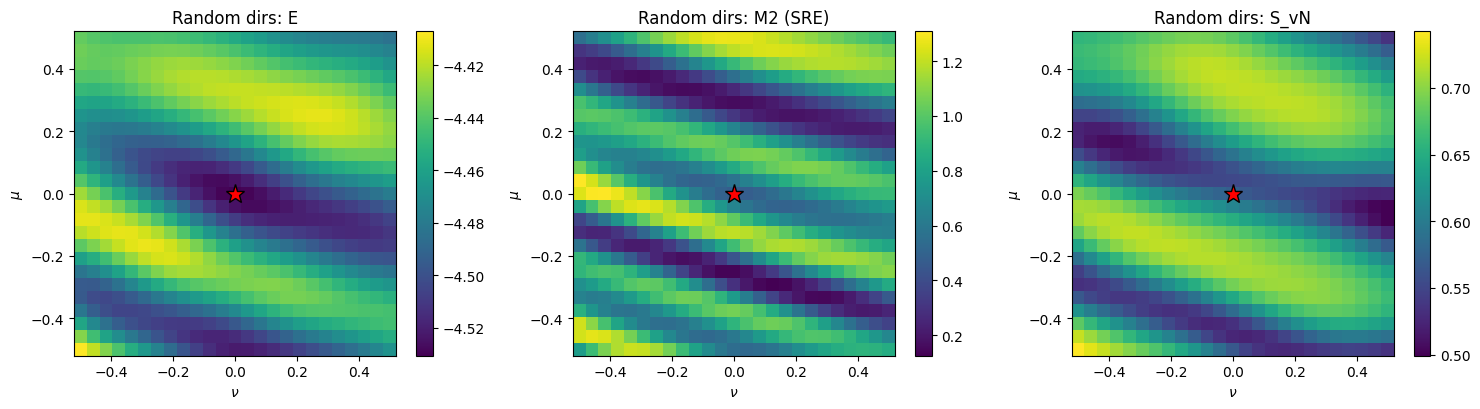

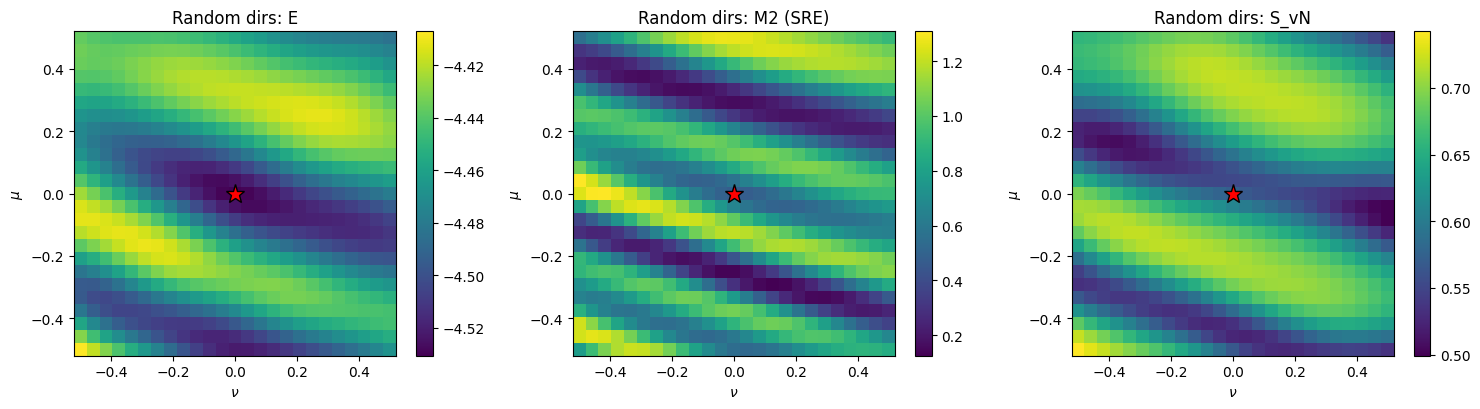

In [8]:
v1_rand, v2_rand = random_orthonormal_directions(len(theta_star), seed=0)

E_rand, M2_rand, S_rand = scan_2d(
    model, theta_star, v1_rand, v2_rand, sector, nqubits, mu_range, nu_range
)
plot_scan(mu_range, nu_range, E_rand, M2_rand, S_rand, title_prefix="Random dirs: ")